##Выполнение тестового задания для стажировки

Есть задание с отбора на стажировку на направление "инженер машинного обучения". Ниже будет его разбор и решение.

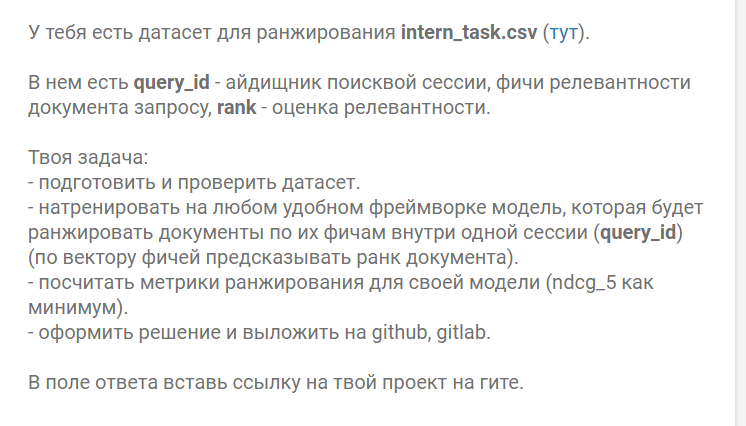

#Загрузка датасета
Датасет скачан и загружается с гугл диска

In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/diff/intern_task.csv")

Выводятся первые 10 строк

In [ ]:
data.head(10)

,rank,query_id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143
0,0,10,1.0,0.0,1.0,3.0,3.0,0.333333,0.0,0.333333,...,0.0,0.000000,0.454545,0.890238,8.655534,1.000000,0.077778,0.002222,1.0,0.333333
1,1,10,3.0,0.0,3.0,0.0,3.0,1.000000,0.0,1.000000,...,0.0,0.000000,0.000000,0.773976,23.130514,0.000000,0.027826,0.000430,44.0,14.666667
2,0,10,3.0,0.0,2.0,0.0,3.0,1.000000,0.0,0.666667,...,0.0,0.000000,0.000000,0.918308,13.351339,0.000000,0.014925,0.000104,22.0,7.333333
3,1,10,3.0,0.0,3.0,0.0,3.0,1.000000,0.0,1.000000,...,0.0,0.000000,0.000000,0.975355,18.240926,0.000000,0.053140,0.000255,8.0,2.666667
4,2,10,3.0,0.0,3.0,1.0,3.0,1.000000,0.0,1.000000,...,273.0,79.670665,0.200000,0.990119,31.786048,0.333333,0.046512,0.000307,24.0,8.000000
5,1,10,3.0,0.0,3.0,1.0,3.0,1.000000,0.0,1.000000,...,0.0,0.000000,0.200000,0.974819,22.936731,0.333333,0.033233,0.000093,28.0,9.333333
6,1,10,3.0,0.0,3.0,0.0,3.0,1.000000,0.0,1.000000,...,3.0,16.200000,0.000000,0.945281,18.240926,0.000000,0.013008,0.000023,5.0,1.666667
7,0,10,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
8,0,10,2.0,0.0,1.0,0.0,2.0,0.666667,0.0,0.333333,...,218.0,55.069946,0.000000,0.448807,4.695805,0.000000,0.002153,0.000002,5.0,1.666667
9,0,10,3.0,0.0,0.0,0.0,3.0,1.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.975608,0.000000,0.000000,0.021583,0.000040,9.0,3.000000


Проверка данных на наличие пропусков:

In [ ]:
print(data.isnull().sum())

rank           0
query_id       0
feature_0      0
feature_1      0
feature_2      0
              ..
feature_139    0
feature_140    0
feature_141    0
feature_142    0
feature_143    0
Length: 146, dtype: int64


Пропусков нет, но ниже на всякий случай показано как заполнить пропуски 0

In [ ]:
data.fillna(0, inplace=True)

Далее деление на выборки и группы.
Столбцы rank и query_id удаляются из выборки, поскольку для обучения они не нужны.


In [ ]:
X = data.drop(['rank', 'query_id'], axis=1)
y = data['rank'].values
# groups = data.groupby('query_id').size().values  # Количество документов в каждой сессии
groups = data['query_id'].values


#Создание модели и обучение

Для работы будет использован алгоритм XGBRanker, созданный специально для задач ранжирования.

Импорт библиотек

In [ ]:
from xgboost import XGBRanker
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupKFold
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.preprocessing import StandardScaler

Заранее добавлен код для вычисления метрики ERR (Expected Reciprocal Rank). Метрика учитывает вероятность остановки пользователя на каждом документе.

In [ ]:
def calculate_err(y_true, y_pred, query_ids, max_grade=5):
    """
    y_true: истинные ранги (вещественные)
    y_pred: предсказанные скоры
    query_ids: идентификаторы групп
    max_grade: максимальный возможный ранг (для нормализации)
    """
    err_scores = []

    for q in np.unique(query_ids):
        mask = query_ids == q
        y_true_q = y_true[mask]
        y_pred_q = y_pred[mask]

        # Сортируем по предсказанным скорам
        ranked_idx = np.argsort(y_pred_q)[::-1]
        y_true_ranked = y_true_q[ranked_idx]

        # Преобразуем ранги в вероятности (по формуле ERR)
        p = (np.power(2, y_true_ranked) - 1) / np.power(2, max_grade)
        r = 1.0
        err = 0.0

        for i in range(len(p)):
            err += (p[i] * r) / (i + 1)
            r *= (1 - p[i])

        err_scores.append(err)

    return np.mean(err_scores)

# err = calculate_err(y[test_idx], preds, groups[test_idx])
# print(f"ERR: {err:.3f}")

Группы (group) — модель учится сравнивать документы только внутри одного query_id.

NDCG — оценивает, насколько порядок ранжирования близок к идеальному.

In [ ]:
# вариант с нормализацией
# Выберите тип нормализации (стандартизация или MinMax)
scaler = StandardScaler()  # или MinMaxScaler()

# кросс-валидация по группам:
kfold = GroupKFold(n_splits=3)
for fold_num, (train_idx, test_idx) in enumerate(kfold.split(X, y, groups), 1):
    # Разделение данных
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Нормализация данных
    # Обучаем scaler только на тренировочных данных, затем применяем к тестовым
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Группировка для train
    train_groups, train_counts = np.unique(groups[train_idx], return_counts=True)

    # 3. Обучение (теперь используем нормализованные данные)
    model = XGBRanker(objective='rank:ndcg')
    model.fit(X_train_scaled, y_train, group=train_counts)

    # 4. Оценка (используем нормализованные тестовые данные)
    preds = model.predict(X_test_scaled)
    ndcg = ndcg_score([y_test], [preds], k=5)
    mse = mean_squared_error(y_test, preds)
    err = calculate_err(y_test, preds, groups[test_idx])

    print(f"""Fold {fold_num} :
    - NDCG@5: {ndcg:.3f}
    - MSE: {mse:.3f}
    - ERR: {err:.3f}""")

Fold 1 :
    - NDCG@5: 1.000
    - MSE: 3.055
    - ERR: 0.215
Fold 2 :
    - NDCG@5: 0.766
    - MSE: 3.100
    - ERR: 0.218
Fold 3 :
    - NDCG@5: 0.927
    - MSE: 2.992
    - ERR: 0.224


Ниже первоначальный вариант без нормализации

In [ ]:
# кросс-валидация по группам:
kfold = GroupKFold(n_splits=3)
for fold_num, (train_idx, test_idx) in enumerate(kfold.split(X, y, groups), 1):
#     X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    # Группировка для train
    train_groups, train_counts = np.unique(groups[train_idx], return_counts=True)

    # 3. Обучение
    model = XGBRanker(objective='rank:ndcg')
    # model.fit(X, y, group=groups)
    model.fit(X.iloc[train_idx], y[train_idx], group=train_counts)
# iloc для доступа по индексу
    # 4. Оценка
    # preds = model.predict(X)
    # print(f"NDCG@5: {ndcg_score([y], [preds], k=5):.3f}")
    preds = model.predict(X.iloc[test_idx])
    ndcg = ndcg_score([y[test_idx]], [preds], k=5)
    mse = mean_squared_error(y[test_idx], preds)
    # top3_mask = np.argsort(preds)[-3:]
    # top3_accuracy = (y[test_idx][top3_mask] > 0).mean()  # Пример бинарной релевантности
    err = calculate_err(y[test_idx], preds, groups[test_idx])


    print(f"""Fold {fold_num} :
    - NDCG@5: {ndcg:.3f}
    - MSE: {mse:.3f}
    - ERR: {err:.3f}""")

Fold 1 :
    - NDCG@5: 0.967
    - MSE: 3.075
    - ERR: 0.215
Fold 2 :
    - NDCG@5: 0.873
    - MSE: 3.084
    - ERR: 0.218
Fold 3 :
    - NDCG@5: 0.934
    - MSE: 2.996
    - ERR: 0.219


NDCG@5 показывает высокие результаты, однако нормализация данных не особо помогла повысить метрику ERR, так что, вероятно, проблема низких показателей в другом.

Вычисление дополнительных метрик (MSE и Точность)

In [ ]:
# После предсказания
mse = mean_squared_error(y[test_idx], preds)
print(f"MSE: {mse:.3f}")

# Топ-3 точность
top3_mask = np.argsort(preds)[-3:]
top3_accuracy = (y[test_idx][top3_mask] > 0).mean()  # Пример бинарной релевантности
print(f"Top-3 Accuracy: {top3_accuracy:.3f}")

err = calculate_err(y[test_idx], preds, groups[test_idx])
print(f"Expected Reciprocal Rank: {err:.3f}")

MSE: 2.996
Top-3 Accuracy: 1.000


Визуализация важности признаков: выводятся 10 самых важных признаков

<Figure size 1000x500 with 0 Axes>

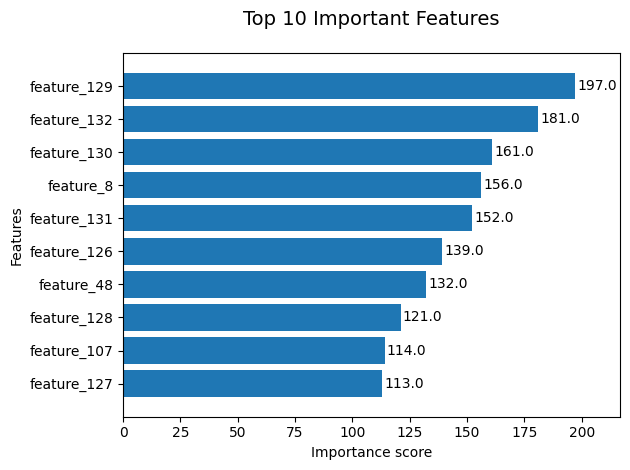

In [ ]:
# важность признаков
# from xgboost import plot_importance
# plot_importance(model)

plt.figure(figsize=(10, 5))
plot_importance(model, max_num_features=10, height=0.8)
plt.title("Top 10 Important Features", pad=20, fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.savefig('features.png', dpi=150)
plt.show()


Причины, по которым ERR низкий:

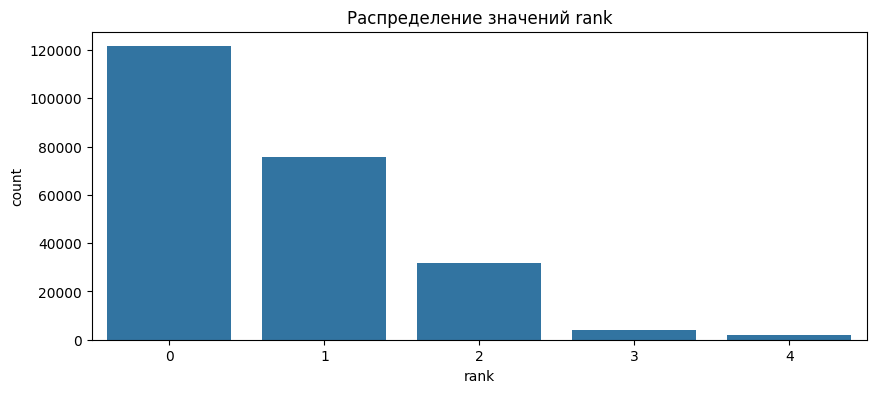

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.countplot(x='rank', data=data)
plt.title("Распределение значений rank")
plt.show()

Большинство документов имеют ранг 0, причем документов с рангом 3 и 4 критически мало -> ERR низкий.

Поскольку релевантность вещественная, а не бинарная, то показатель ERR низкий так же по причине того, что метрика ориентирована для бинарной релеватности.